In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Model from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)

In [3]:
import duckdb

parquet_filename = "../data/processed/tac_co2_formatted_v1.parquet"
duckdb.sql(f"DESCRIBE SELECT * FROM '{parquet_filename}'").df()

,column_name,column_type,null,key,default,extra
0,date,BIGINT,YES,None,None,None
1,time,BIGINT,YES,None,None,None
2,type,VARCHAR,YES,None,None,None
3,sample,VARCHAR,YES,None,None,None
4,standard,VARCHAR,YES,None,None,None
5,port,BIGINT,YES,None,None,None
6,co2_dry,DOUBLE,YES,None,None,None
7,co2_wet,DOUBLE,YES,None,None,None
8,co2_stdev,DOUBLE,YES,None,None,None
9,co2_std_rep,VARCHAR,YES,None,None,None


In [4]:
raw_data = duckdb.sql(f"SELECT * FROM '{parquet_filename}'").df()
raw_data.head(20)

,date,time,type,sample,standard,port,co2_dry,co2_wet,co2_stdev,co2_std_rep,co2_std_stdev,co2_target_error,co2_Cdrift,co2_C,co2_N,co2_Nfiltered,cycle_time,h2o,h2o_stdev,cavity_press,cavity_press_stdev,cavity_temp,cavity_temp_stdev,das_temp,etalon_temp,warmbox_temp,outlet_valve,co2_flag
0,120111,162730,unknown,-,USN-20112109,0,403.464,403.606,1.063,None,None,None,406.303,406.300,0,100.0,3.733,-0.02232,0.00175,140.00525,0.01396,44.90277,0.01251,32.14167,44.77072,None,31442.617,x
1,120111,162830,unknown,-,USN-20112109,0,402.944,403.085,1.308,None,None,None,405.779,405.776,0,100.0,3.733,-0.02232,0.00170,140.00435,0.01518,44.92952,0.00415,32.36250,44.91882,None,31543.971,x
2,120111,162930,unknown,-,USN-20112109,0,400.992,401.133,1.802,None,None,None,403.813,403.811,0,100.0,3.733,-0.02243,0.00221,140.00513,0.01176,44.93352,0.00128,32.59792,44.99702,None,31626.549,x
3,120111,163030,unknown,-,USN-20112109,0,401.753,401.893,1.516,None,None,None,404.580,404.577,0,100.0,3.733,-0.02217,0.00256,140.00745,0.01437,44.92616,0.00253,32.81506,45.02549,None,31687.379,x
4,120111,163130,unknown,-,USN-20112109,0,401.479,401.622,0.743,None,None,None,404.304,404.301,0,100.0,3.625,-0.02259,0.00192,140.00314,0.01321,44.91914,0.00165,32.98813,45.02443,None,31726.805,x
5,120111,163230,unknown,-,USN-20112109,0,401.215,401.356,0.619,None,None,None,404.038,404.035,0,100.0,3.733,-0.02248,0.00258,139.99792,0.01910,44.91655,0.00026,33.13750,45.00900,None,31758.904,F
6,120111,163330,unknown,-,USN-20112109,0,401.416,401.565,0.727,None,None,None,404.241,404.238,0,100.0,3.500,-0.02362,0.00115,140.00032,0.01554,44.91776,0.00100,33.26172,44.98967,None,31785.496,F
7,120111,163430,unknown,-,USN-20112109,0,404.622,404.779,2.342,None,None,None,407.469,407.466,0,100.0,3.500,-0.02471,0.00000,140.00146,0.01652,44.92261,0.00181,33.35547,44.97134,None,31807.650,F
8,120111,163530,unknown,-,USN-20112109,0,401.350,401.506,2.698,None,None,None,404.174,404.171,0,100.0,3.500,-0.02471,0.00000,139.99977,0.01241,44.92999,0.00249,33.42248,44.95708,None,31827.049,F
9,120111,163630,unknown,-,USN-20112109,0,410.890,411.049,3.356,None,None,None,413.781,413.777,0,100.0,3.471,-0.02471,0.00000,140.00076,0.01586,44.93916,0.00306,33.47794,44.94679,None,31844.387,F


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 28 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date                int64  
 1   time                int64  
 2   type                object 
 3   sample              object 
 4   standard            object 
 5   port                int64  
 6   co2_dry             float64
 7   co2_wet             float64
 8   co2_stdev           float64
 9   co2_std_rep         object 
 10  co2_std_stdev       object 
 11  co2_target_error    object 
 12  co2_Cdrift          float64
 13  co2_C               float64
 14  co2_N               int64  
 15  co2_Nfiltered       float64
 16  cycle_time          float64
 17  h2o                 float64
 18  h2o_stdev           float64
 19  cavity_press        float64
 20  cavity_press_stdev  float64
 21  cavity_temp         float64
 22  cavity_temp_stdev   float64
 23  das_temp            float64
 24  etalon_temp         floa

In [6]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{parquet_filename}'").df()

,column_name,column_type,null,key,default,extra
0,date,BIGINT,YES,None,None,None
1,time,BIGINT,YES,None,None,None
2,type,VARCHAR,YES,None,None,None
3,sample,VARCHAR,YES,None,None,None
4,standard,VARCHAR,YES,None,None,None
5,port,BIGINT,YES,None,None,None
6,co2_dry,DOUBLE,YES,None,None,None
7,co2_wet,DOUBLE,YES,None,None,None
8,co2_stdev,DOUBLE,YES,None,None,None
9,co2_std_rep,VARCHAR,YES,None,None,None


In [7]:
raw_data.isna().sum()

date                        0
time                        0
type                        0
sample                      0
standard                    0
port                        0
co2_dry                     0
co2_wet                     0
co2_stdev                   0
co2_std_rep            503888
co2_std_stdev          195164
co2_target_error       837870
co2_Cdrift             150884
co2_C                  150884
co2_N                       0
co2_Nfiltered         5720928
cycle_time                  0
h2o                    186418
h2o_stdev              187687
cavity_press                0
cavity_press_stdev          0
cavity_temp                 0
cavity_temp_stdev           0
das_temp                    0
etalon_temp                 0
warmbox_temp          1200534
outlet_valve                0
co2_flag                92122
dtype: int64

In [8]:
std_cols = ['co2_stdev', 'co2_std_rep', 'co2_std_stdev',
            'h2o_stdev',  'cavity_press_stdev','cavity_temp_stdev',]

In [9]:
df_v1 = raw_data.copy()
df_v1 = df_v1.drop(columns = std_cols)
df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6828990 entries, 0 to 6828989
Data columns (total 22 columns):
 #   Column            Dtype  
---  ------            -----  
 0   date              int64  
 1   time              int64  
 2   type              object 
 3   sample            object 
 4   standard          object 
 5   port              int64  
 6   co2_dry           float64
 7   co2_wet           float64
 8   co2_target_error  object 
 9   co2_Cdrift        float64
 10  co2_C             float64
 11  co2_N             int64  
 12  co2_Nfiltered     float64
 13  cycle_time        float64
 14  h2o               float64
 15  cavity_press      float64
 16  cavity_temp       float64
 17  das_temp          float64
 18  etalon_temp       float64
 19  warmbox_temp      object 
 20  outlet_valve      float64
 21  co2_flag          object 
dtypes: float64(12), int64(4), object(6)
memory usage: 1.1+ GB


In [10]:
print(df_v1['co2_flag'].unique())
print(df_v1['co2_flag'].isna().sum())

['x' 'F' ' ' None '*']
92122


In [11]:
df_v1[df_v1['co2_flag'].isna()].head(20)
# it results in 'NaN' because when slicing, if there is a trailing 'nana' followed by a space
# it fails to display and simply fills the entire section with blanks.
df_v1['co2_flag'] = df_v1['co2_flag'].fillna(' ')
# fill in ' ' (normal)

In [12]:
print(df_v1['co2_flag'].isna().sum())

0


---

In [13]:
flag_cov = {
    ' ': 0,
    'F':1,
    'x':1,
    '*': 1
}
df_v1['label1'] = df_v1['co2_flag'].map(flag_cov).astype(int)
df_v1.tail()

,date,time,type,sample,standard,port,co2_dry,co2_wet,co2_target_error,co2_Cdrift,co2_C,co2_N,co2_Nfiltered,cycle_time,h2o,cavity_press,cavity_temp,das_temp,etalon_temp,warmbox_temp,outlet_valve,co2_flag,label1
6828985,250722,70630,air,185m,CFF-011,10,434.581,434.312,0.051,437.130,437.131,16,NaN,3.625,0.03994,139.99831,45.00000,33.04913,45.07225,45.0,33654.016,,0
6828986,250722,70730,air,185m,CFF-011,10,435.568,435.297,0.051,438.123,438.124,16,NaN,3.562,0.04013,139.99857,45.00006,33.00881,45.07200,45.0,33653.953,,0
6828987,250722,70830,air,185m,CFF-011,10,436.272,436.002,0.051,438.831,438.832,17,NaN,3.471,0.03988,139.99689,44.99976,33.00000,45.07159,44.99929,33653.434,,0
6828988,250722,70930,air,185m,CFF-011,10,435.444,435.175,0.051,437.998,437.999,16,NaN,3.625,0.03981,140.00513,44.99944,32.97287,45.07100,44.999,33658.930,,0
6828989,250722,71030,air,185m,CFF-011,10,435.163,434.895,0.051,437.716,437.717,16,NaN,3.625,0.03981,139.99606,44.99900,32.94081,45.07094,44.9985,33655.355,,0


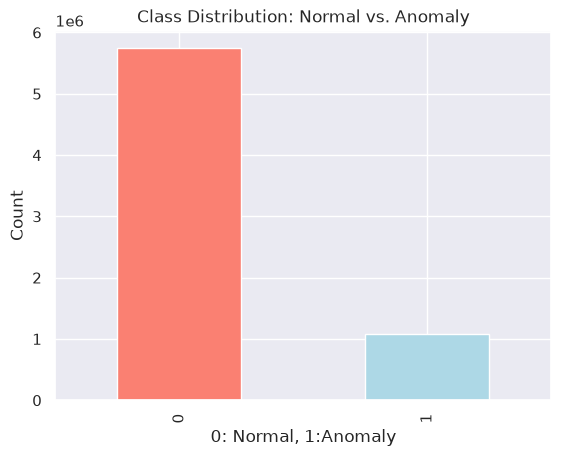

In [14]:
df_v1['label1'].value_counts().plot.bar(color=['salmon', 'lightblue'])
plt.title('Class Distribution: Normal vs. Anomaly')
plt.xlabel('0: Normal, 1:Anomaly')
plt.ylabel('Count')
plt.show()

In [15]:
df_v1.columns

Index(['date', 'time', 'type', 'sample', 'standard', 'port', 'co2_dry',
       'co2_wet', 'co2_target_error', 'co2_Cdrift', 'co2_C', 'co2_N',
       'co2_Nfiltered', 'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 'co2_flag',
       'label1'],
      dtype='object')

In [16]:
needed_col = [ 'port', 'co2_dry',
       'co2_wet', 'co2_target_error', 'co2_Cdrift', 'co2_C', 'co2_N',
       'co2_Nfiltered', 'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 
       'label1']
object_col = ['co2_target_error', 'warmbox_temp'] 

In [17]:
df_v1[object_col] = df_v1[object_col].astype('float32')


In [18]:
corr = df_v1[needed_col].corr()

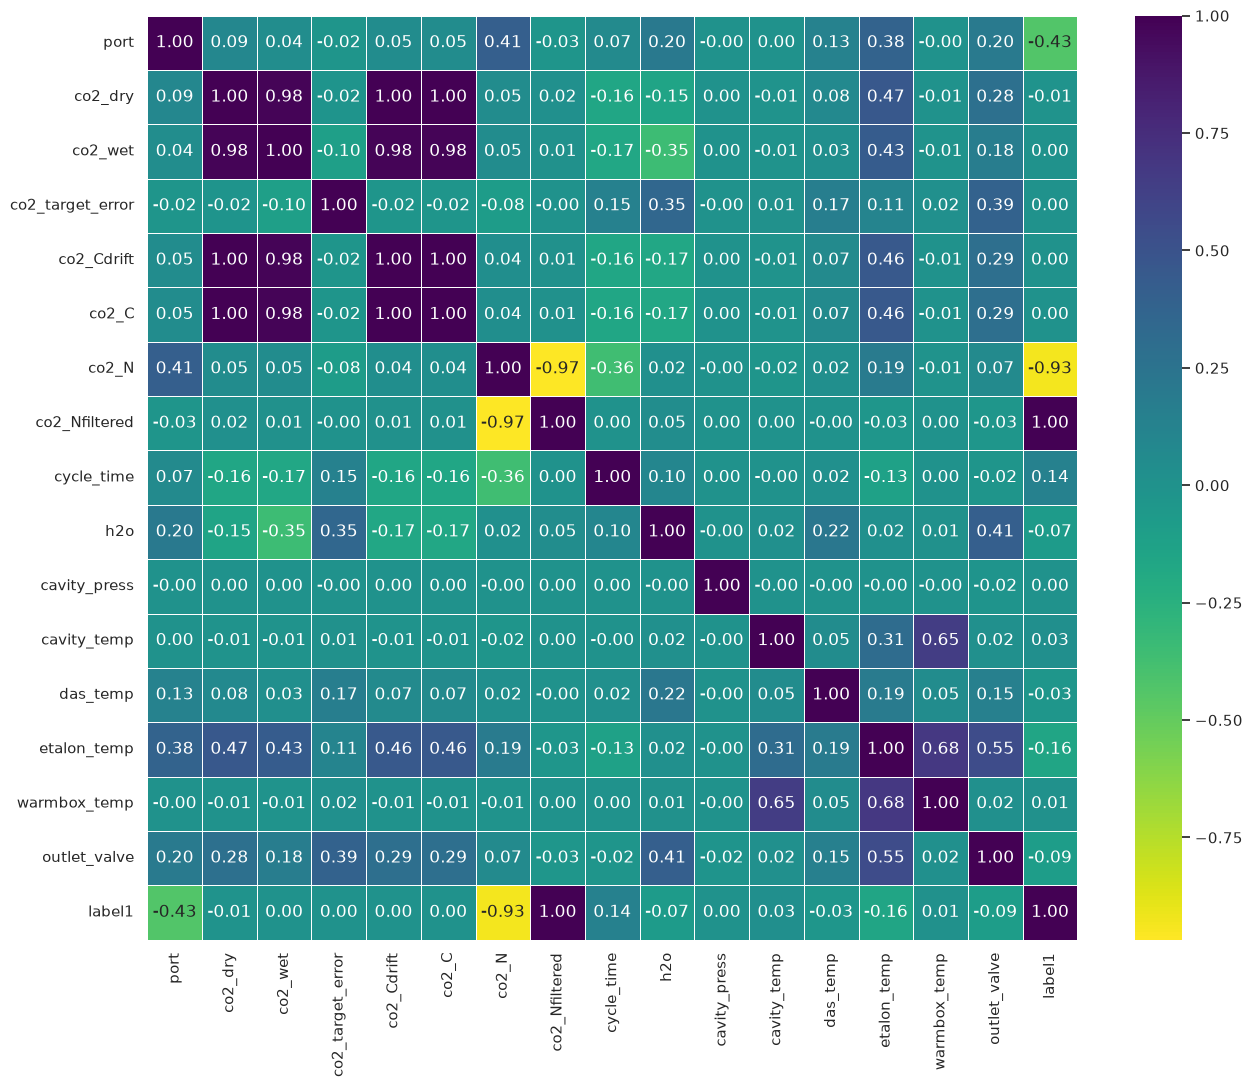

In [19]:
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='viridis_r',
    fmt='.2f',
    linewidths=0.5
)
plt.show()

In [20]:
needed_col_v3 = [ #'port',
         'co2_dry','co2_wet', 
         'co2_target_error', 
         #'co2_Cdrift', 'co2_C', 'co2_N','co2_Nfiltered', 
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 
       'label1']

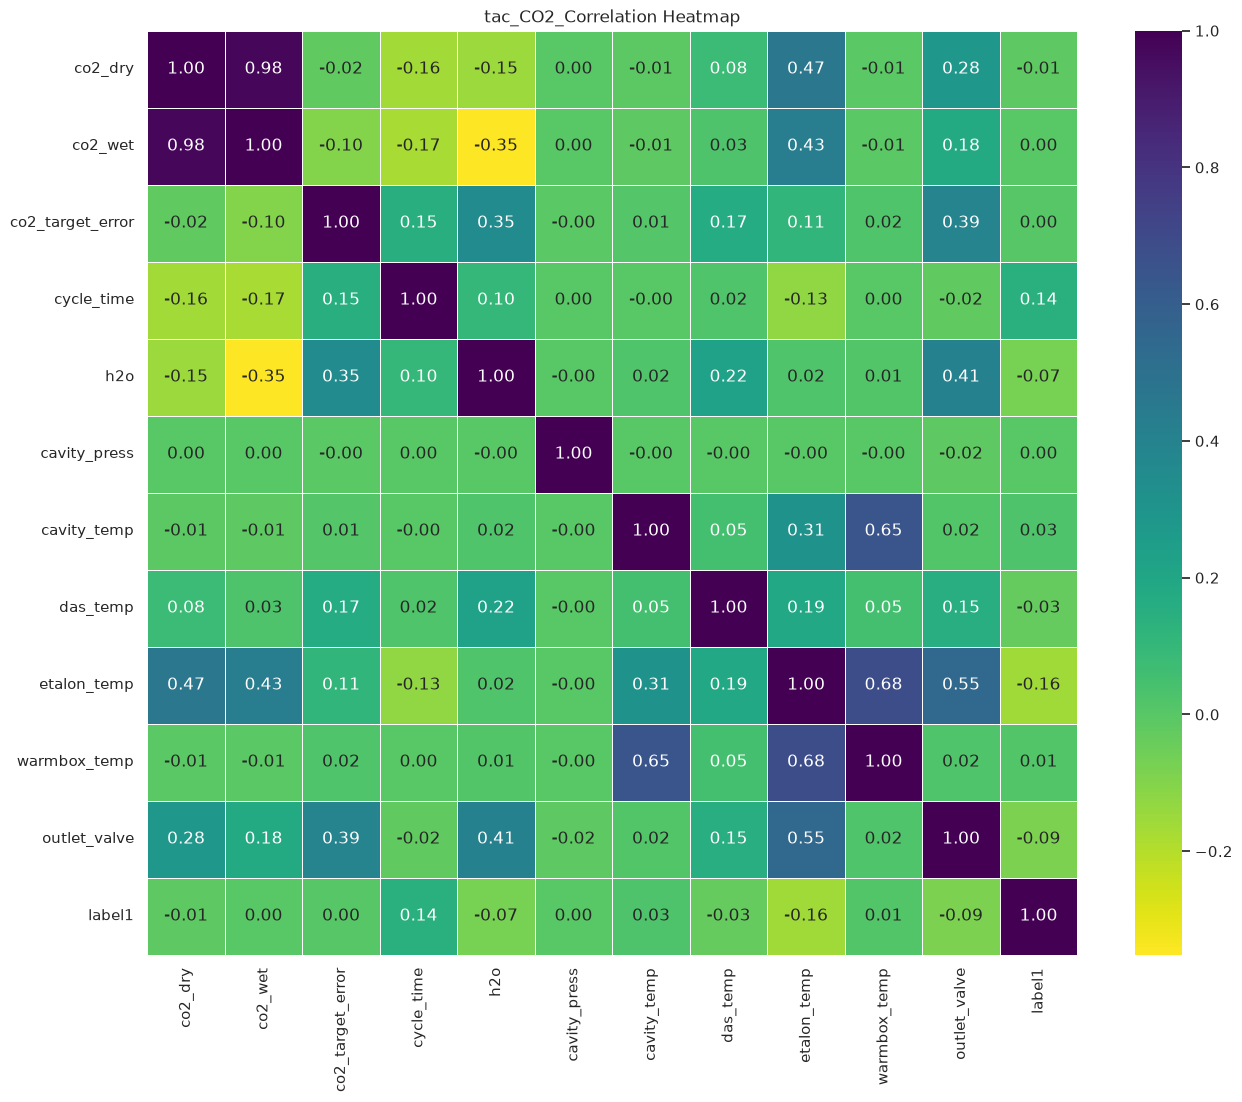

In [21]:


df_v1[needed_col_v3] = df_v1[needed_col_v3].astype('float32')

corr = df_v1[needed_col_v3].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='viridis_r',
    fmt='.2f',
    linewidths=0.5
)
plt.title('tac_CO2_Correlation Heatmap')
plt.show()

----

In [22]:
df_v1['date'] = df_v1['date'].astype(str).str.zfill(6)
df_v1['time'] = df_v1['time'].astype(str).str.zfill(6)

df_v1['datetime_str'] = df_v1['date'] + df_v1['time']

df_v1['datetime'] = pd.to_datetime(df_v1['datetime_str'], format='%y%m%d%H%M%S')

df_v1.head(20)

,date,time,type,sample,standard,port,co2_dry,co2_wet,co2_target_error,co2_Cdrift,co2_C,co2_N,co2_Nfiltered,cycle_time,h2o,cavity_press,cavity_temp,das_temp,etalon_temp,warmbox_temp,outlet_valve,co2_flag,label1,datetime_str,datetime
0,120111,162730,unknown,-,USN-20112109,0,403.463989,403.605988,NaN,406.303,406.300,0,100.0,3.733,-0.02232,140.005249,44.902771,32.141670,44.770721,NaN,31442.617188,x,1.0,120111162730,2012-01-11 16:27:30
1,120111,162830,unknown,-,USN-20112109,0,402.944000,403.084991,NaN,405.779,405.776,0,100.0,3.733,-0.02232,140.004349,44.929520,32.362499,44.918819,NaN,31543.970703,x,1.0,120111162830,2012-01-11 16:28:30
2,120111,162930,unknown,-,USN-20112109,0,400.992004,401.132996,NaN,403.813,403.811,0,100.0,3.733,-0.02243,140.005127,44.933521,32.597919,44.997021,NaN,31626.548828,x,1.0,120111162930,2012-01-11 16:29:30
3,120111,163030,unknown,-,USN-20112109,0,401.752991,401.893005,NaN,404.580,404.577,0,100.0,3.733,-0.02217,140.007446,44.926159,32.815060,45.025490,NaN,31687.378906,x,1.0,120111163030,2012-01-11 16:30:30
4,120111,163130,unknown,-,USN-20112109,0,401.479004,401.622009,NaN,404.304,404.301,0,100.0,3.625,-0.02259,140.003143,44.919140,32.988129,45.024429,NaN,31726.804688,x,1.0,120111163130,2012-01-11 16:31:30
5,120111,163230,unknown,-,USN-20112109,0,401.214996,401.355988,NaN,404.038,404.035,0,100.0,3.733,-0.02248,139.997925,44.916550,33.137501,45.008999,NaN,31758.904297,F,1.0,120111163230,2012-01-11 16:32:30
6,120111,163330,unknown,-,USN-20112109,0,401.415985,401.565002,NaN,404.241,404.238,0,100.0,3.500,-0.02362,140.000320,44.917759,33.261719,44.989670,NaN,31785.496094,F,1.0,120111163330,2012-01-11 16:33:30
7,120111,163430,unknown,-,USN-20112109,0,404.622009,404.778992,NaN,407.469,407.466,0,100.0,3.500,-0.02471,140.001465,44.922611,33.355469,44.971340,NaN,31807.650391,F,1.0,120111163430,2012-01-11 16:34:30
8,120111,163530,unknown,-,USN-20112109,0,401.350006,401.506012,NaN,404.174,404.171,0,100.0,3.500,-0.02471,139.999771,44.929989,33.422482,44.957081,NaN,31827.048828,F,1.0,120111163530,2012-01-11 16:35:30
9,120111,163630,unknown,-,USN-20112109,0,410.890015,411.049011,NaN,413.781,413.777,0,100.0,3.471,-0.02471,140.000763,44.939159,33.477940,44.946789,NaN,31844.386719,F,1.0,120111163630,2012-01-11 16:36:30


In [23]:

df_v1['datetime'] = pd.to_datetime(df_v1['datetime'])

df_v1['year'] =df_v1['datetime'].dt.year
df_v1['month']=df_v1['datetime'].dt.month
df_v1['day']=df_v1['datetime'].dt.day
df_v1['hour']=df_v1['datetime'].dt.hour
df_v1['minute']=df_v1['datetime'].dt.minute
df_v1['seconds']=df_v1['datetime'].dt.second

In [25]:
df_v1.to_parquet('../data/processed/tac_co2_processed_v1.parquet', index=True)

-----------

In [24]:
df_v1.head()

,date,time,type,sample,standard,port,co2_dry,co2_wet,co2_target_error,co2_Cdrift,co2_C,co2_N,co2_Nfiltered,cycle_time,h2o,cavity_press,cavity_temp,das_temp,etalon_temp,warmbox_temp,outlet_valve,co2_flag,label1,datetime_str,datetime,year,month,day,hour,minute,seconds
0,120111,162730,unknown,-,USN-20112109,0,403.463989,403.605988,NaN,406.303,406.300,0,100.0,3.733,-0.02232,140.005249,44.902771,32.141670,44.770721,NaN,31442.617188,x,1.0,120111162730,2012-01-11 16:27:30,2012,1,11,16,27,30
1,120111,162830,unknown,-,USN-20112109,0,402.944000,403.084991,NaN,405.779,405.776,0,100.0,3.733,-0.02232,140.004349,44.929520,32.362499,44.918819,NaN,31543.970703,x,1.0,120111162830,2012-01-11 16:28:30,2012,1,11,16,28,30
2,120111,162930,unknown,-,USN-20112109,0,400.992004,401.132996,NaN,403.813,403.811,0,100.0,3.733,-0.02243,140.005127,44.933521,32.597919,44.997021,NaN,31626.548828,x,1.0,120111162930,2012-01-11 16:29:30,2012,1,11,16,29,30
3,120111,163030,unknown,-,USN-20112109,0,401.752991,401.893005,NaN,404.580,404.577,0,100.0,3.733,-0.02217,140.007446,44.926159,32.815060,45.025490,NaN,31687.378906,x,1.0,120111163030,2012-01-11 16:30:30,2012,1,11,16,30,30
4,120111,163130,unknown,-,USN-20112109,0,401.479004,401.622009,NaN,404.304,404.301,0,100.0,3.625,-0.02259,140.003143,44.919140,32.988129,45.024429,NaN,31726.804688,x,1.0,120111163130,2012-01-11 16:31:30,2012,1,11,16,31,30


In [22]:
df_v2 = df_v1.copy()
df_v2 = df_v1.drop(df_v1[df_v1['year']==2026].index)
print(df_v2['year'].unique())
print(df_v2.columns)

[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Index(['date', 'time', 'type', 'sample', 'standard', 'port', 'co2_dry',
       'co2_wet', 'co2_target_error', 'co2_Cdrift', 'co2_C', 'co2_N',
       'co2_Nfiltered', 'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 'co2_flag',
       'label1', 'datetime_str', 'datetime', 'year', 'month', 'day', 'hour',
       'minute', 'seconds'],
      dtype='object')


In [23]:
df_v2.isna().sum()

date                      0
time                      0
type                      0
sample                    0
standard                  0
port                      0
co2_dry                   0
co2_wet                   0
co2_target_error     837870
co2_Cdrift           150884
co2_C                150884
co2_N                     0
co2_Nfiltered       5720928
cycle_time                0
h2o                  186418
cavity_press              0
cavity_temp               0
das_temp                  0
etalon_temp               0
warmbox_temp        1200534
outlet_valve              0
co2_flag                  0
label1                    0
datetime_str              0
datetime                  0
year                      0
month                     0
day                       0
hour                      0
minute                    0
seconds                   0
dtype: int64

In [27]:
df_v2[needed_col_v3].isna().sum()

co2_dry                   0
co2_wet                   0
co2_target_error     837870
cycle_time                0
h2o                  186418
cavity_press              0
cavity_temp               0
das_temp                  0
etalon_temp               0
warmbox_temp        1200534
outlet_valve              0
label1                    0
dtype: int64

In [28]:
df_v2[needed_col_v3].describe()

,co2_dry,co2_wet,co2_target_error,cycle_time,h2o,cavity_press,cavity_temp,das_temp,etalon_temp,warmbox_temp,outlet_valve,label1
count,6.828990e+06,6.828990e+06,5.991120e+06,6.828990e+06,6.642572e+06,6.828990e+06,6.828990e+06,6.828990e+06,6.828990e+06,5.628456e+06,6.828990e+06,6.828990e+06
mean,4.122819e+02,4.088202e+02,4.118158e-02,3.748383e+00,5.550234e-01,1.399991e+02,4.500041e+01,3.564734e+01,4.503887e+01,4.500009e+01,3.357993e+04,1.590658e-01
std,1.461073e+01,1.529649e+01,3.333825e-02,8.294214e-01,5.118658e-01,7.034064e-01,3.589169e-02,2.302908e+00,2.920387e-02,1.553545e-02,1.503626e+03,3.657375e-01
min,0.000000e+00,0.000000e+00,4.000000e-03,2.333000e+00,-2.471000e-02,1.385718e+02,4.455700e+01,2.696117e+01,4.469521e+01,4.474028e+01,0.000000e+00,0.000000e+00
25%,4.032550e+02,3.993720e+02,1.600000e-02,3.353000e+00,4.700000e-02,1.399959e+02,4.499981e+01,3.385219e+01,4.502300e+01,4.500000e+01,3.320342e+04,0.000000e+00
50%,4.121650e+02,4.078860e+02,3.400000e-02,3.562000e+00,4.516100e-01,1.399989e+02,4.500000e+01,3.563237e+01,4.504300e+01,4.500000e+01,3.400734e+04,0.000000e+00
75%,4.209790e+02,4.175200e+02,5.300000e-02,3.733000e+00,9.652500e-01,1.400018e+02,4.500019e+01,3.717750e+01,4.506000e+01,4.500006e+01,3.449400e+04,0.000000e+00
max,2.225534e+03,2.220696e+03,7.960000e-01,1.000000e+01,5.299207e+01,7.559886e+02,5.228594e+01,6.088662e+01,4.911687e+01,4.908281e+01,3.967148e+04,1.000000e+00


warmbox_temp range from 44~45, not highly related to label1
co2_target_error not highly related to label1, try remove it
h2o -> forward filling, -0.07 related to label1s 
 

In [29]:
ml_col = [ 'port',
         'co2_dry','co2_wet', 
         #'co2_target_error', 
         #'co2_Cdrift', 'co2_C', 'co2_N','co2_Nfiltered', 
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 
       #'label1'
]

In [30]:
ml_df = df_v2.copy()

In [31]:
ml_df['warmbox_temp']=ml_df['warmbox_temp'].fillna(45)

In [32]:
ml_df.isna().sum()

date                      0
time                      0
type                      0
sample                    0
standard                  0
port                      0
co2_dry                   0
co2_wet                   0
co2_target_error     837870
co2_Cdrift           150884
co2_C                150884
co2_N                     0
co2_Nfiltered       5720928
cycle_time                0
h2o                  186418
cavity_press              0
cavity_temp               0
das_temp                  0
etalon_temp               0
warmbox_temp              0
outlet_valve              0
co2_flag                  0
label1                    0
datetime_str              0
datetime                  0
year                      0
month                     0
day                       0
hour                      0
minute                    0
seconds                   0
dtype: int64

In [33]:
def fill_Nan(df, feature_col):
    df = df.copy()
    for i in feature_col:
        df[i] = df[i].ffill()
    return df

In [34]:
feature_cols =[ 'port',
         'co2_dry','co2_wet', 
         #'co2_target_error', 
         #'co2_Cdrift', 'co2_C', 'co2_N','co2_Nfiltered', 
       'cycle_time', 'h2o', 'cavity_press', 'cavity_temp',
       'das_temp', 'etalon_temp', 'warmbox_temp', 'outlet_valve', 
       #'label1'
]

In [35]:
X = ml_df[ml_col]
y = ml_df['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(ml_df)*0.8)


X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Handle nan values, forwardfill
X_train_filled = fill_Nan(X_train, feature_cols)
X_test_filled = fill_Nan(X_test, feature_cols)

In [36]:
# scaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

In [37]:
X_train_scaled.shape, X_test.shape, y_train.shape, y_test.shape

((5463192, 11), (1365798, 11), (5463192,), (1365798,))

## rf model 

In [37]:
def best_threshold(X_test, model, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions *recalls) / (precisions + recalls+ 1e-7) # 1e-7 to prevent Nan

    best_idx = np.argmax(f1_scores[:-1])
    best_thres = thresholds[best_idx]

    print(f"Best threshold: {best_thres}")
    print(f"Best F1-score: {f1_scores[best_idx]:.4f}")
    print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
   
def plot_importance(model, feature_names, title_suffix=""):
    """
    plotting Feature importance, and upload to MLflow automatically
    """
    print
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(10, 15))
    importances.plot(kind='barh', ax=ax)

    title = f'Feature Importance ({title_suffix})' if title_suffix else "Feature Importance"
    ax.set_title(title)
    fig.tight_layout()

    plt.show()
    plt.close(fig)


def random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, 
                        max_depth=12, n_jobs=-1, threshold=0.5, class_weight=None):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth = max_depth,
    random_state=42,
    n_jobs = n_jobs,
    class_weight=class_weight)


    model.fit(X_train, y_train)

    # evaluation and recording Metrics
    y_proba = model.predict_proba(X_test)[:, 1]
    #y_pred = model.predict(X_test)
    y_pred = (y_proba > threshold).astype(int) # threshold should be 0.05 or something
    
    acc = accuracy_score(y_test, y_pred)

    print("Model training completed!")
    print(classification_report(y_test, y_pred))

    cm =confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax =plt.subplots(figsize=(6,6))
    disp.plot(ax=ax,cmap=plt.cm.Blues)
    plt.title(f'Normalized Confusion Matrix, threshold:{threshold}')
    # upload figure to mlflow
    plot_path = f'image/0626_confusion_matrix_{threshold}.png' # to produce the real confusion matrix plot to cover the mlflow autolog's(threshold=0.5 default) 
    plt.savefig(plot_path)
    plt.close()
    print(model.feature_importances_)
    return model
    #plot_importance(model, feature_names, title_suffix=experiment_run_name)

In [ ]:
all_results = []
rf_model = random_forest_model(
        X_train_scaled , y_train, X_test_scaled,  y_test,
        feature_names=feature_cols,
        experiment_run_name=f'rf_first_test', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
best_threshold(X_test_scaled, rf_model, y_test)

Model Training

In [39]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':KNeighborsClassifier(n_neighbors = 2),
    'RandomForestClassier':RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42, n_jobs=-1)
}

def modelfit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluate ML models.
    models: dictionary of different ML models
    X_train: training data (no labels)
    X_test: testinh data (no labels)
    y_train: training labels
    y_test: testing labels
    returns model scores dictionary
    """
    precision_val = 2.0
    np.random.seed(42)

    model_scores = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # focuse on anomaly 
        precision_val = precision_score(y_test, y_pred, pos_label=1)

        model_scores[model_name] = precision_val
        print(f'---- { model_name} Report')
        print(classification_report(y_test, y_pred))

    return model_scores

In [ ]:
model_scores= modelfit_and_score(models, X_train_scaled, X_test_filled, y_train, y_test)
print("Anomaly dettection precision:", model_scores)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---- Logistic Regression Report


/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94   1204021
         1.0       0.00      0.00      0.00    161777

    accuracy                           0.88   1365798
   macro avg       0.44      0.50      0.47   1365798
weighted avg       0.78      0.88      0.83   1365798



/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


---- KNN Report
              precision    recall  f1-score   support

         0.0       0.87      0.52      0.65   1204021
         1.0       0.11      0.43      0.17    161777

    accuracy                           0.51   1365798
   macro avg       0.49      0.48      0.41   1365798
weighted avg       0.78      0.51      0.60   1365798



In [ ]:
def ratio_featutre_gen(df):
    df = df.copy()
    df['CH4_area_ht_ratio'] = df['CH4_area']/df['CH4_ht']
    df['CH4_w_ht_ratio'] = df['CH4_w']/df['CH4_ht']
    df['psamp_pflow_ratio'] = df['psamp']/df['pflow']
    df['w_duration_ratio'] = df['CH4_w']/df['duration']

    fill_feature_ratio = ['CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio','w_duration_ratio']
    for i in fill_feature_ratio :
        df[i] = df[i].fillna(0)
        
    return df

#=============== diff, lag, rolling
def diff_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_diff_{period}'] = (df[f'{feature}'].diff(period)).fillna(0)

    return df
#===============
def lag_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_lag_{period}'] = (df[f'{feature}'].shift(period)).fillna(0)
    return df

#===============
def rolling_std_gen (df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_std_{period}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').std()).fillna(0)# self not included, NAN->0
    return df

#===============
def rolling_mean_residual_gen(df, feature, period):
    df = df.copy()
    df[f'{feature}_roll_mean_{period}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(period), closed='left').mean().fillna(0) # self not included
    df[f'{feature}_residual_{period}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{period}']# self not included
    return df

### Random Forest

In [ ]:
X = rf_df[feature_cols]
y = rf_df['label1']
feature_cols = X.columns.tolist()
split_idx = int(len(ml_df)*0.8)


X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final.head()

X_train_final = X_train.copy()
X_test_final = X_test.copy()

# set date as index
X_train_final  =X_train_final.set_index('datetime')
X_test_final = X_test_final.set_index('datetime')

# fill NAN values
X_train_final = fill_Nan(X_train_final, eng_cols)
X_test_final= fill_Nan(X_test_final, eng_cols)

# create ratio feature
X_train_final  = ratio_featutre_gen(X_train_final)
X_test_final= ratio_featutre_gen(X_test_final)

# conver date index as pd datatime type
X_train_final.index = pd.to_datetime(X_train_final.index)
X_test_final.index = pd.to_datetime(X_test_final.index)


feature_config ={
    'diff':{'cols': ['CH4_area', 'CH4_ht', 'CH4_rt'], 'periods':1},
    'lag':{'cols':['CH4_area', 'CH4_rt', 'tmod', 'tamb','pflow', 'psamp','pamb'], 'periods':1 },
    'roll_std':{'cols': ['CH4_w', 'CH4_skew'], 'period':'14D'},
    'roll_mean_res':{'cols':['CH4_rt', 'CH4_start_time', 'CH4_w', 'CH4_skew'], 'period': '14D'}
}


def feature_eng_apply(df, config):
    df = df.copy()

    for opt, params in config.items():
        cols = params['cols']
        period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

        for feature in cols:
            if opt == 'diff':
                df = diff_gen(df, feature, period)
            elif opt == 'lag':
                df = lag_gen(df, feature, period)
            elif opt == 'roll_std':
                df = rolling_std_gen(df, feature, period)
            elif opt == 'roll_mean_res':
                df = rolling_mean_residual_gen(df, feature, period)
    return df 


X_train_final= feature_eng_apply(X_train_final, feature_config)
X_test_final= feature_eng_apply(X_test_final, feature_config)



all_results = []
rf_model = random_forest_model(
        X_train_final, y_train, X_test_final,  y_test,
        feature_names=model_features,
        experiment_run_name=f'rf_first_test', n_estimators=200, max_depth=12, n_jobs=-1,
        threshold=0.5,class_weight=None
    )
best_threshold(X_test_final, rf_model, y_test)


In [ ]:
RocCurveDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--')
plt.show()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf_model, X_test_final, y_test)

plt.title('Precision-Recall Curve')
plt.show()